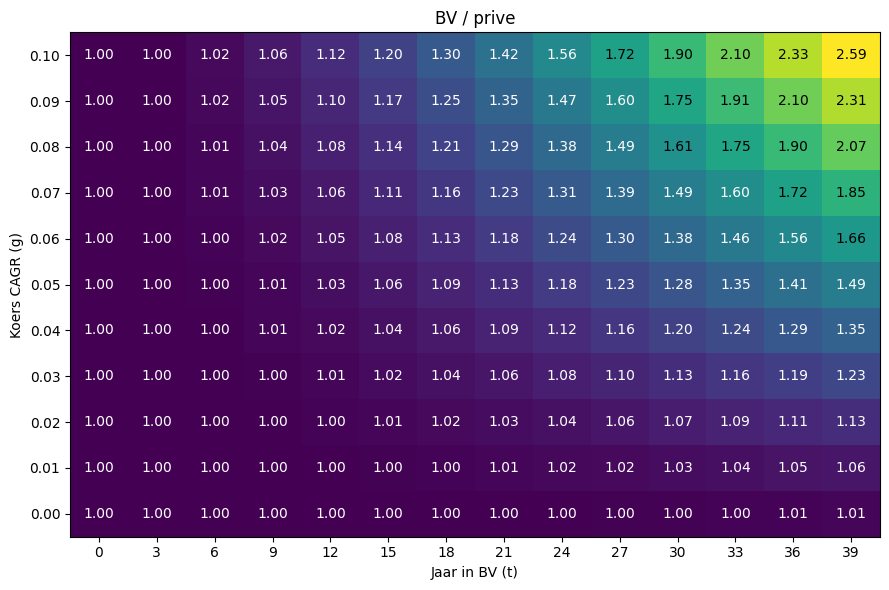

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

ts = np.arange(0, 41, 3)
gs = np.linspace(0, 0.1, 11)

b = 0.245
a = 0.36
v = 0.19
d = 0.02

T, G = np.meshgrid(ts, gs)

ratio = (
    ((b - 1) * (v - 1) * (d + G) * ((d * (-v) + d + G + 1) ** T - 1))
    / (d * (-v) + d + G)
    + 1
) / (1 + (d + G) * (1 - a)) ** T


fig, ax = plt.subplots(figsize=(9, 6))

norm = LogNorm(vmin=ratio.min(), vmax=ratio.max())

im = ax.imshow(
    ratio,
    cmap="viridis",
    norm=norm,
    origin="lower",
    aspect="auto",
)

ax.set_xticks(np.arange(len(ts)))
ax.set_xticklabels(ts)
ax.set_yticks(np.arange(len(gs)))
ax.set_yticklabels([f"{g:.2f}" for g in gs])

ax.set_xlabel("Jaar in BV (t)")
ax.set_ylabel("Koers CAGR (g)")
ax.set_title("BV / prive")

# annotate cells
for i in range(len(gs)):
    for j in range(len(ts)):
        value = ratio[i, j]

        # choose text color based on brightness
        color = "white" if norm(value) < 0.5 else "black"

        ax.text(
            j, i, f"{value:.2f}", ha="center", va="center", color=color, fontsize=10
        )

plt.tight_layout()
plt.show()